In [88]:
import pandas as pd
import numpy as np

# --- Задание 1 ---

# Загружаем файл, оставляя в датафрейме только перечисленные столбцы
columns = ['surgery?', 'Age', 'rectal temperature', 'pulse',
           'respiratory rate', 'temperature of extremities',
           'pain', 'outcome']
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/horse_data.csv', usecols = [1-1, 2-1, 4-1, 5-1,
                                              6-1, 7-1, 11-1, 23-1], names=columns, na_values='?')
df.head()

,surgery?,Age,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
0,2.0,1,38.5,66.0,28.0,3.0,5.0,2.0
1,1.0,1,39.2,88.0,20.0,NaN,3.0,3.0
2,2.0,1,38.3,40.0,24.0,1.0,3.0,1.0
3,1.0,9,39.1,164.0,84.0,4.0,2.0,2.0
4,2.0,1,37.3,104.0,35.0,NaN,NaN,2.0


In [ ]:
# --- Задание 2 ---
# Изучаем данные и для начала выведем describe.
df.describe()

,surgery?,Age,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
count,299.000000,300.000000,240.000000,276.000000,242.000000,244.000000,245.00000,299.000000
mean,1.397993,1.640000,38.167917,71.913043,30.417355,2.348361,2.95102,1.551839
std,0.490305,2.173972,0.732289,28.630557,17.642231,1.045054,1.30794,0.737187
min,1.000000,1.000000,35.400000,30.000000,8.000000,1.000000,1.00000,1.000000
25%,1.000000,1.000000,37.800000,48.000000,18.500000,1.000000,2.00000,1.000000
50%,1.000000,1.000000,38.200000,64.000000,24.500000,3.000000,3.00000,1.000000
75%,2.000000,1.000000,38.500000,88.000000,36.000000,3.000000,4.00000,2.000000
max,2.000000,9.000000,40.800000,184.000000,96.000000,4.000000,5.00000,3.000000


Как мы видим, больше всего пропусков по показаниям температуры, частоте дыхания и характеру боли.
Последнее не всегда можно оценить объективно, но что касается остальных показателей - тут
пропуски связаны, вероятно, с отсутствием самого факта измерений по тем или иным причинам.

In [ ]:
df['Age'].value_counts()

,count
Age,
1,276
9,24


Видим, что в выборке 276 взрослых особи и, видимо, 24 жеребенка (будем считать, что это так, и при составлении датасета кто-то перепутал 2 (в описании) и 9 (в данных))

In [ ]:
# выведем уникальные значения температуры для оценки наличия выбросов
df['rectal temperature'].unique()

array([38.5, 39.2, 38.3, 39.1, 37.3,  nan, 37.9, 38.1, 37.2, 38. , 38.2,
       37.6, 37.5, 39.4, 39.9, 38.4, 38.6, 37.8, 37.7, 39. , 35.4, 38.9,
       37.4, 40.3, 37. , 39.7, 38.7, 36.4, 38.8, 39.6, 36.8, 39.5, 36.5,
       36. , 37.1, 39.3, 36.1, 36.6, 40.8, 36.9, 40. ])

In [ ]:
# выведем информацию о средней температуре по конюшне
df['rectal temperature'].mean()

np.float64(38.16791666666667)

Средняя температура выше нормы

In [ ]:
# мода и медиана
df['rectal temperature'].mode()[0]
df['rectal temperature'].median()

38.2

В описании сказано, что нормальная температура составляет 37.8. Полученные нами расчеты говорят о повышенной средней температуре по конюшне.

In [ ]:
# создадим новую выборку, из лошадей, которые имеют повышенную температуру
high_temp = df[df['rectal temperature'] > 37.8]

In [ ]:
# посмотрим, сколько же лошадей имеют повышенную температуру
high_temp['rectal temperature'].count()

np.int64(167)

Более половины лошадей (167) имеют повышенную температуру.

In [ ]:
# Посмотрим данные по пульсу
print(df['pulse'].unique())
print(df['pulse'].mode()[0])
print(df['pulse'].mean())
print(df['pulse'].median())
print(df['pulse'].min())
print(df['pulse'].max())

[ 66.  88.  40. 164. 104.  nan  48.  60.  80.  90.  72.  42.  92.  76.
  96. 128.  64. 110. 130. 108. 100. 112.  52. 146. 150. 120. 140.  84.
  46. 114. 160.  54.  56.  38.  98.  50.  44.  70.  78.  49.  30. 136.
 132.  65.  86. 129.  68.  36.  45. 124. 184.  75.  82.]
48.0
71.91304347826087
64.0
30.0
184.0


Чаще всего встречаются лошади с пульсом 48. Половина из лошадей имеют пульс больше 64.
По значению моды = 48, видно, что пульс по выборке выше нормы.

Посчитаем СКО для значений температуры и пульса до заполнения пропусков:

In [ ]:
print('Температура:')
print(df['rectal temperature'].std())
print('Пульс:')
print(df['pulse'].std())

Температура:
0.7322886641121578
Пульс:
28.630556660735003


Посчитаем дисперсию для значений температуры и пульса до заполнения пропусков:

In [ ]:
print('Температура:')
print(df['rectal temperature'].var())
print('Пульс:')
print(df['pulse'].var())

Температура:
0.5362466875871686
Пульс:
819.7087747035575


Оценим выбросы по показаниям пульса:

In [ ]:
Q1_pls = df['pulse'].quantile(0.25)
Q3_pls = df['pulse'].quantile(0.75)
IQR_pls = Q3_pls - Q1_pls
IQR_pls

np.float64(40.0)

In [ ]:
# Диапазон, куда выбросы НЕ входят
lower_bound_pls = Q1_pls - (1.5 * IQR_pls)
upper_bound_pls = Q3_pls + (1.5 * IQR_pls)

In [ ]:
# Есть ли эти самые выбросы?
print(len(df[~df['pulse'].between(lower_bound_pls, upper_bound_pls)]))

29


In [ ]:
# Посмотрим, что это за выбросы?
df[~df['pulse'].between(lower_bound_pls, upper_bound_pls)]

,surgery?,Age,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
3,1.0,9,39.1,164.0,84.0,4.0,2.0,2.0
5,2.0,1,NaN,NaN,NaN,2.0,2.0,1.0
28,1.0,1,NaN,NaN,NaN,NaN,NaN,2.0
41,2.0,9,39.0,150.0,72.0,NaN,NaN,1.0
52,2.0,1,NaN,NaN,NaN,1.0,1.0,1.0
55,1.0,9,38.6,160.0,20.0,3.0,3.0,2.0
56,1.0,1,NaN,NaN,NaN,NaN,NaN,1.0
58,1.0,1,NaN,NaN,20.0,4.0,5.0,2.0
74,1.0,9,NaN,NaN,NaN,NaN,NaN,2.0
78,1.0,1,NaN,NaN,NaN,3.0,5.0,2.0


В выбросы попали лошади с явно завышенным пульсом в 3.5 - 4 раза выше нормы.
И все они, как мы приняли выше, молодые особи (Age = 9) (не верится, чтобы у жеребцов пульс 150-180 был нормальным..)

Теперь аналогично оценим выбросы по температуре и частоте дыхания

In [ ]:
# Ищем выбросы по температуре
# IQR температуры
Q1_rctl = df['rectal temperature'].quantile(0.25)
Q3_rctl = df['rectal temperature'].quantile(0.75)
IQR_rctl = Q3_rctl - Q1_rctl
IQR_rctl

np.float64(0.7000000000000028)

In [ ]:
# Диапазон, куда выбросы НЕ входят
lower_bound_rctl = Q1_rctl - (1.5 * IQR_rctl)
upper_bound_rctl = Q3_rctl + (1.5 * IQR_rctl)

In [ ]:
# Есть ли эти самые выбросы?
print(len(df[~df['rectal temperature'].between(lower_bound_rctl, upper_bound_rctl)]))

74


In [ ]:
# Посмотрим, что это за выбросы?
df[~df['rectal temperature'].between(lower_bound_rctl, upper_bound_rctl)]

,surgery?,Age,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
5,2.0,1,NaN,NaN,NaN,2.0,2.0,1.0
7,1.0,1,NaN,60.0,NaN,3.0,NaN,2.0
8,2.0,1,NaN,80.0,36.0,3.0,4.0,3.0
16,1.0,9,NaN,128.0,36.0,3.0,4.0,2.0
20,1.0,1,39.9,72.0,60.0,1.0,5.0,1.0
...,...,...,...,...,...,...,...,...
282,1.0,1,NaN,70.0,16.0,3.0,2.0,2.0
288,1.0,1,NaN,NaN,NaN,NaN,NaN,1.0
293,1.0,1,NaN,78.0,24.0,3.0,NaN,3.0
295,1.0,1,NaN,120.0,70.0,4.0,2.0,3.0


In [ ]:
# Ищем выбросы по частоте дыхания
# IQR частоты дыхания
Q1_respiratore = df['respiratory rate'].quantile(0.25)
Q3_respiratore = df['respiratory rate'].quantile(0.75)
IQR_respiratore = Q3_respiratore - Q1_respiratore
print(IQR_respiratore)

17.5


In [ ]:
# Диапазон, куда выбросы НЕ входят данные по дыханию
lower_bound_respiratore = Q1_respiratore - (1.5 * IQR_respiratore)
upper_bound_respiratore = Q3_respiratore + (1.5 * IQR_respiratore)

In [ ]:
# Есть ли эти самые выбросы по дыханию?
print(len(df[~df['respiratory rate'].between(lower_bound_respiratore, upper_bound_respiratore)]))

75


In [ ]:
# что это за выбросы по дыханию?
df[~df['respiratory rate'].between(lower_bound_respiratore, upper_bound_respiratore)]

,surgery?,Age,rectal temperature,pulse,respiratory rate,temperature of extremities,pain,outcome
3,1.0,9,39.1,164.0,84.0,4.0,2.0,2.0
5,2.0,1,NaN,NaN,NaN,2.0,2.0,1.0
7,1.0,1,NaN,60.0,NaN,3.0,NaN,2.0
9,2.0,9,38.3,90.0,NaN,1.0,5.0,1.0
28,1.0,1,NaN,NaN,NaN,NaN,NaN,2.0
...,...,...,...,...,...,...,...,...
274,1.0,1,NaN,76.0,NaN,NaN,NaN,3.0
281,2.0,1,40.0,78.0,NaN,3.0,2.0,2.0
284,2.0,1,38.5,54.0,NaN,1.0,3.0,1.0
288,1.0,1,NaN,NaN,NaN,NaN,NaN,1.0


В выбросы по температуре попали лошади с высокой и низкой температуре, а также NAN.
В выбросы по дыханию попади лошади с частотой дыхания в 8 и более раз выше нормы.

Попробуем визуализировать зависимость исхода (outcome) от ключевых параметров:

In [45]:
# для наглядности:

df['Age'].replace({9:2})
df['outcome'].replace({1:'lived', 2:'died', 3:'euthenized'})
df['Age'].replace({1:'Adult', 2:'Young'})
df['pain'].replace({1:'No Pain', 2:'Depressed', 3:'Mild pain', 4:'Severe Pain', 5:'Extra pain'})
df['surgery?'].replace({1:'Yes', 2:'No'})

,surgery?
0,No
1,Yes
2,No
3,Yes
4,No
...,...
295,Yes
296,No
297,Yes
298,Yes


outcome
lived         178
died           77
euthenized     44
Name: count, dtype: int64


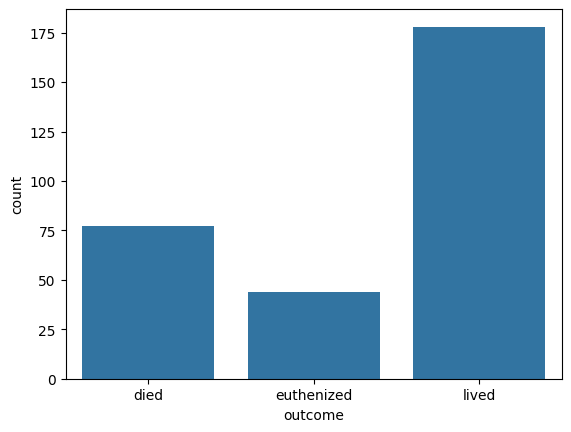

In [46]:
import seaborn as sns

sns.countplot(data=df, x="outcome");
print(df.outcome.value_counts())

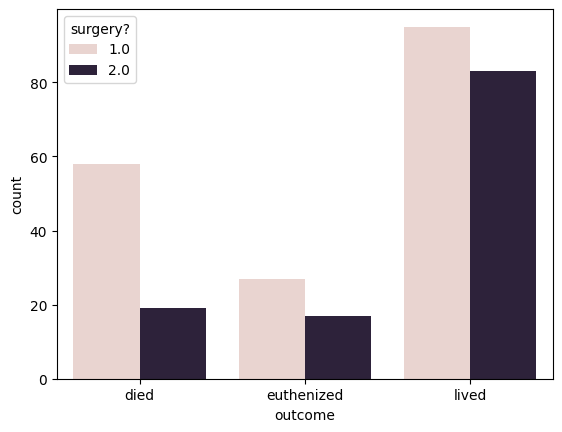

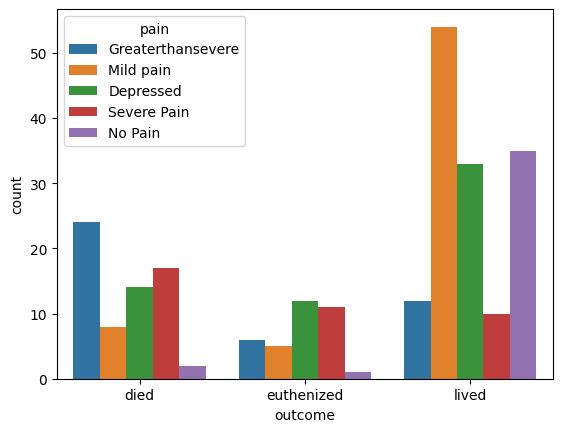

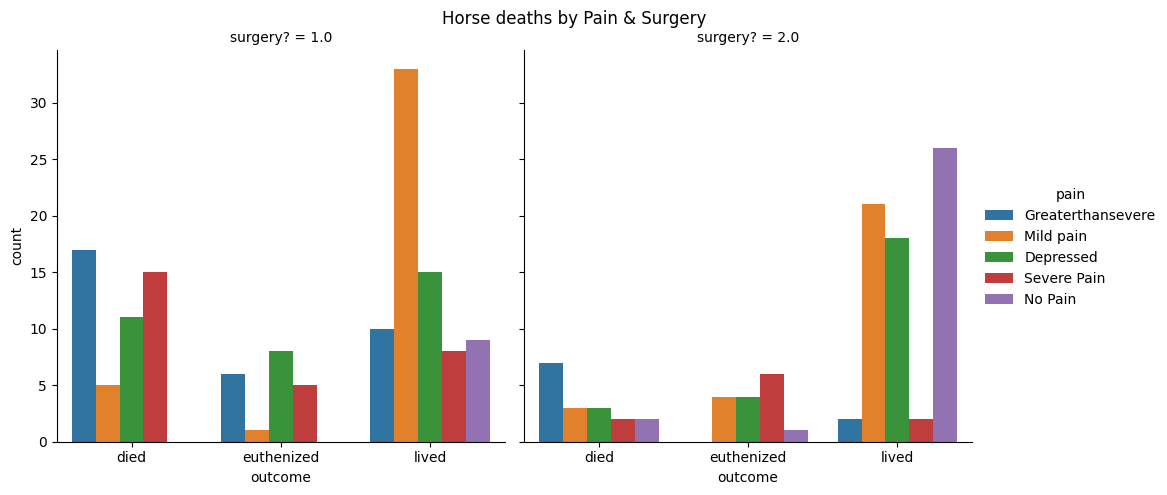

In [47]:
from matplotlib import pyplot as plt

sns.countplot(data=df, x='outcome', hue='surgery?');
plt.show()

sns.countplot(data=df, x='outcome', hue='pain');
plt.show()

g = sns.catplot(data=df, x='outcome', col='surgery?', hue='pain', kind='count');
g.fig.suptitle('Horse deaths by Pain & Surgery');
plt.subplots_adjust(top=0.9)

Пока можно сказать, что:

- 20 из 77 погибших лошадей не дождались операции. О них забыли?
- 18 лошадей перенесли операцию, но их усыпили.
- Подавляющее большинство погибших лошадей испытывали сильную или тяжелую боль. - В то время как большинство усыпленных лошадей испытывали сильную боль или были на обезболивающих.
- Из всех лошадей, которые умерли и не перенесли операцию, большинство испытывали сильную боль.
- Из всех лошадей, которые не перенесли операцию и были усыплены, большинство испытывали сильную боль.

Посмотрим распределение по пульсу:

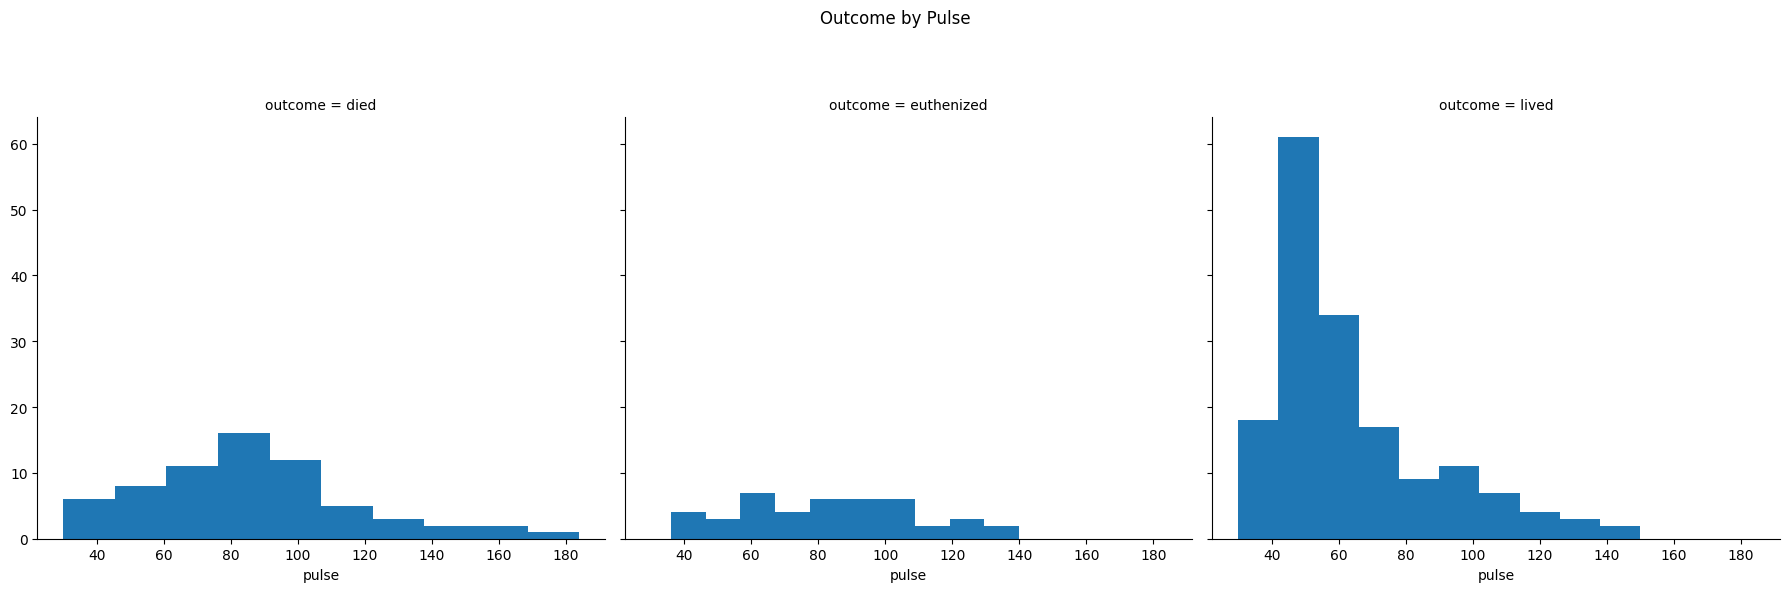

In [49]:
g = sns.FacetGrid(data=df, col='outcome', margin_titles=True, height=6)
g.map(plt.hist, 'pulse')
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Outcome by Pulse');

У большинства погибших лошадей пульс составлял примерно 80–100 ударов в минуту.

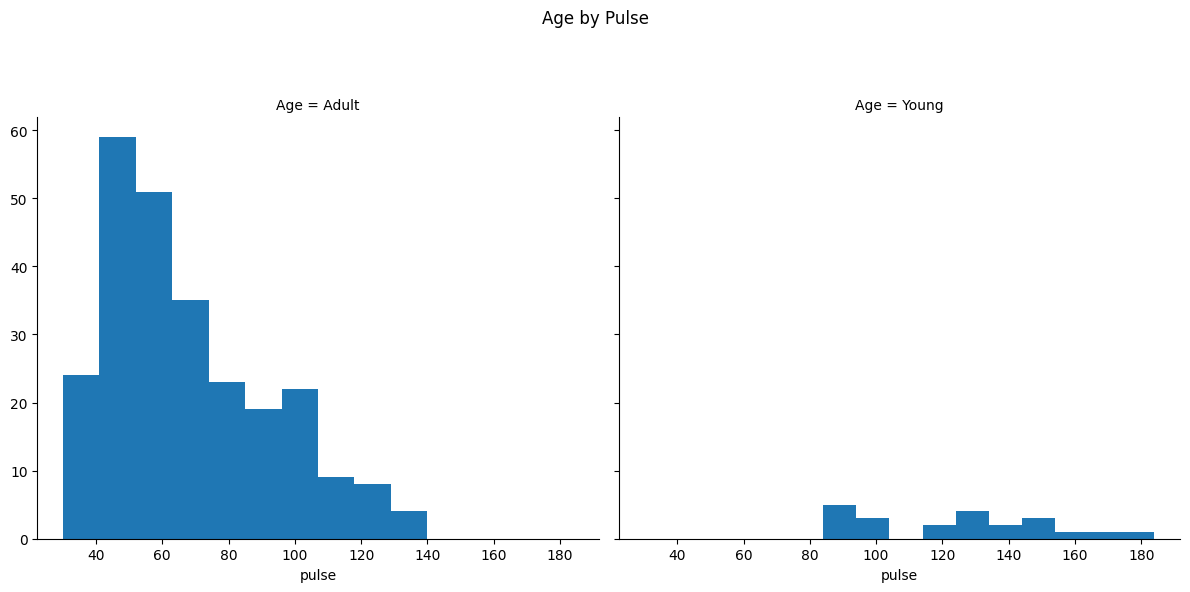

In [57]:
g = sns.FacetGrid(data=df, col='Age', margin_titles=True, height=6)
g.map(plt.hist, 'pulse')
plt.subplots_adjust(top=0.8)
g.fig.suptitle('Age by Pulse');

Видим по распределению смещение пульса у взрослых особей в сторону значений ниже среднего. У молодых пульс завышен, и, видимо, это все-таки нормально.

Cвязь outcome с показателями жизнедеятельности:

In [53]:
df.groupby('outcome')['pulse'].median()

,pulse
outcome,
died,86.0
euthenized,82.0
lived,54.0


In [54]:
df.groupby('outcome')['respiratory rate'].median()

,respiratory rate
outcome,
died,30.0
euthenized,24.0
lived,24.0


In [55]:
df.groupby('outcome')['rectal temperature'].median()

,rectal temperature
outcome,
died,38.10
euthenized,38.05
lived,38.20


Данные в столбцах могут быть как непрерывными, так и категориальными.

Что касается непрерывных данных:
1. Видно, что взаимосвязь между рект. температурой, частотой дыхания и исходом не выражена, поэтому, так как есть достаточно большое количество выбросов, будем заполнять пропущенные значения медианой, а не средним.

2. В то же время, зависимость исхода от частоты пульса более выражена.
Пропущенные значения по пульсу будем заполнять средним, так как выбросов нет (мы выдвинули гипотезу, что повышенный пульс до 180 является нормальным для молодых особей).

Категориальные данные - surgery, outcome, pain, temperature of extremities - заполняем модой.

In [113]:
df_result = df.copy()

In [114]:
# заполнение пропусков в непрерывных данных

df_result['respiratory rate'] = df_result['respiratory rate'].fillna(df_result['respiratory rate'].median())
df_result['rectal temperature'] = df_result['rectal temperature'].fillna(df_result['rectal temperature'].median())
df_result['pulse'] = df_result['pulse'].fillna(df_result['pulse'].mean())

In [116]:
# заполнение пропусков в категориальных данных

df_result['surgery?'] = df_result['surgery?'].fillna(df_result['surgery?'].mode()[0])
df_result['temperature of extremities'] = df_result['temperature of extremities'].fillna(df_result['temperature of extremities'].mode()[0])
df_result['pain'] = df_result['pain'].fillna(df_result['pain'].mode()[0])
df_result['outcome'] = df_result['outcome'].fillna(df_result['outcome'].mode()[0])

In [117]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   surgery?                    300 non-null    float64
 1   Age                         300 non-null    int64  
 2   rectal temperature          300 non-null    float64
 3   pulse                       300 non-null    float64
 4   respiratory rate            300 non-null    float64
 5   temperature of extremities  300 non-null    float64
 6   pain                        300 non-null    float64
 7   outcome                     300 non-null    float64
dtypes: float64(7), int64(1)
memory usage: 18.9 KB
